In [2]:
!pip install faiss-cpu matplotlib scipy scikit-learn pandas numpy openpyxl


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python -m pip install --upgrade pip


In [3]:
import numpy as np
import scipy.sparse as sp
import faiss
import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix
from scipy.optimize import linear_sum_assignment
from sklearn.model_selection import train_test_split

import sys
from pathlib import Path
root = Path.cwd()
if not (root / "modules").is_dir():
    REPO_ROOT = root.parent
sys.path.insert(0, str(REPO_ROOT))
from utilities.utils import *
from utilities.data_loader import load_embeddings

In [4]:
def balanced_subset(
    X,
    y,
    max_samples=10000,
    random_state=42
):
    """
    Create a class-balanced subset.

    Parameters
    ----------
    X : np.ndarray
        Embeddings/features

    y : np.ndarray
        Labels

    max_samples : int
        Total subset size

    Returns
    -------
    X_sub, y_sub
    """

    X_sub, _, y_sub, _ = train_test_split(
        X,
        y,
        train_size=max_samples,
        stratify=y,
        random_state=random_state
    )

    return X_sub, y_sub

def target_distribution(q):
    weight = (q ** 2) / torch.sum(q, dim=0)
    return (weight.t() / torch.sum(weight, dim=1)).t()


def cluster_delta(y_prev, y_curr):
    cm = confusion_matrix(y_prev, y_curr)
    row_ind, col_ind = linear_sum_assignment(-cm)
    matched = cm[row_ind, col_ind].sum()
    return 1 - matched / len(y_prev)


def build_knn_graph(
    X,
    topk=10,
    metric="cosine"
):
    """
    Unified graph construction for BOTH:
    - TF-IDF + PCA/SVD
    - SBERT embeddings

    Uses cosine similarity by default.
    """

    X = X.astype(np.float32).copy()

    N, d = X.shape

    if metric == "cosine":

        faiss.normalize_L2(X)

        index = faiss.IndexFlatIP(d)

    elif metric == "euclidean":

        index = faiss.IndexFlatL2(d)

    else:
        raise ValueError(f"Unsupported metric: {metric}")

    index.add(X)

    sims, indices = index.search(X, topk + 1)

    rows = []
    cols = []
    vals = []

    for i in range(N):

        for j, sim in zip(indices[i][1:], sims[i][1:]):

            rows.append(i)
            cols.append(j)

            if metric == "euclidean":
                sim = np.exp(-sim)

            vals.append(float(sim))

    adj = sp.coo_matrix(
        (vals, (rows, cols)),
        shape=(N, N),
        dtype=np.float32
    )

    # Symmetrize
    adj = adj.maximum(adj.T)

    # Self-loops
    adj = adj + sp.eye(adj.shape[0], dtype=np.float32)

    deg = np.array(adj.sum(1)).flatten()

    deg_inv_sqrt = 1.0 / np.sqrt(deg + 1e-10)

    D_inv_sqrt = sp.diags(deg_inv_sqrt)

    adj = D_inv_sqrt @ adj @ D_inv_sqrt

    adj = adj.tocsr()
    adj.eliminate_zeros()

    return adj


def sparse_to_torch(adj):

    adj = adj.tocoo()

    indices = torch.from_numpy(
        np.vstack((adj.row, adj.col))
    ).long()

    values = torch.from_numpy(adj.data).float()

    shape = torch.Size(adj.shape)

    return torch.sparse_coo_tensor(
        indices,
        values,
        shape
    )

def cross_view_contrastive_loss(
    semantic_proj,
    structural_proj,
    temperature=0.5
):
    """
    Symmetric cross-view InfoNCE loss.

    Each sample's semantic representation is treated as
    the positive match for the same sample's structural
    representation.
    """

    # Similarity matrix: [N, N]
    logits = torch.matmul(
        semantic_proj,
        structural_proj.T
    ) / temperature

    # Same sample = positive pair
    labels = torch.arange(
        semantic_proj.size(0),
        device=semantic_proj.device
    )

    # Semantic -> Structural
    loss_s2t = F.cross_entropy(logits, labels)

    # Structural -> Semantic
    loss_t2s = F.cross_entropy(logits.T, labels)

    # Symmetric objective
    loss = 0.5 * (loss_s2t + loss_t2s)

    return loss

class AE(nn.Module):
    def __init__(self, n_input, n_enc_1=256, n_enc_2=128, n_enc_3=64, n_z=64):
        super().__init__()

        self.enc_1 = nn.Linear(n_input, n_enc_1)
        self.enc_2 = nn.Linear(n_enc_1, n_enc_2)
        self.enc_3 = nn.Linear(n_enc_2, n_enc_3)
        self.z_layer = nn.Linear(n_enc_3, n_z)

        self.dec_1 = nn.Linear(n_z, n_enc_3)
        self.dec_2 = nn.Linear(n_enc_3, n_enc_2)
        self.dec_3 = nn.Linear(n_enc_2, n_enc_1)
        self.x_bar = nn.Linear(n_enc_1, n_input)

    def forward(self, x):
        h1 = F.relu(self.enc_1(x))
        h2 = F.relu(self.enc_2(h1))
        h3 = F.relu(self.enc_3(h2))
        z = self.z_layer(h3)

        d1 = F.relu(self.dec_1(z))
        d2 = F.relu(self.dec_2(d1))
        d3 = F.relu(self.dec_3(d2))
        x_hat = self.x_bar(d3)

        return x_hat, h1, h2, h3, z


class GCNLayer(nn.Module):

    def __init__(self, in_dim, out_dim):

        super().__init__()

        self.linear = nn.Linear(in_dim, out_dim)

    def forward(self, x, adj, active=True):

        x = self.linear(x)

        x = torch.sparse.mm(adj, x)

        if active:
            x = F.relu(x)

        return x


class SDCN(nn.Module):
    def __init__(
        self,
        n_input,
        n_z,
        n_clusters,
        sigma,
        use_ae=True,
        semantic_dim=None,
        gamma=1.0,
        use_semantic_refine=False,
        use_cross_view_contrastive=False,
        
    ):
        super().__init__()

        self.sigma = sigma
        self.use_ae = use_ae
        self.gamma = gamma
        self.use_semantic_refine = use_semantic_refine and use_ae
        self.use_cross_view_contrastive = (use_cross_view_contrastive and use_ae)

        # When AE is off, cluster directly in input space (z = x)
        if not use_ae:
            n_z = n_input

        self.n_z = n_z

        # AE (only when enabled)
        self.ae = AE(n_input=n_input, n_z=n_z) if use_ae else None

        # Semantic refiner: original SBERT -> n_z, used only at final GCN delivery
        if self.use_semantic_refine:
            if semantic_dim is None:
                raise ValueError("semantic_dim is required when use_semantic_refine=True")
            self.semantic_refiner = nn.Sequential(
                nn.Linear(semantic_dim, 128),
                nn.ReLU(),
                nn.Linear(128, n_z),
            )
        else:
            self.semantic_refiner = None

        # Cross-view contrastive projection heads
        if self.use_cross_view_contrastive:
            self.semantic_projection = nn.Sequential(
                nn.Linear(n_z, 128),
                nn.ReLU(),
                nn.Linear(128, 64),
            )

            self.structural_projection = nn.Sequential(
                nn.Linear(n_z, 128),
                nn.ReLU(),
                nn.Linear(128, 64),
            )
        else:
            self.semantic_projection = None
            self.structural_projection = None


        # GCN
        self.gnn_1 = GCNLayer(n_input, 256)
        self.gnn_2 = GCNLayer(256, 128)
        self.gnn_3 = GCNLayer(128, 64)
        self.gnn_4 = GCNLayer(64, n_z)
        self.gnn_5 = GCNLayer(n_z, n_clusters)

        # clustering
        self.cluster_layer = nn.Parameter(torch.Tensor(n_clusters, n_z))
        nn.init.xavier_normal_(self.cluster_layer.data)

        self.v = 1.0

    def soft_assign(self, z):
        dist = torch.sum((z.unsqueeze(1) - self.cluster_layer) ** 2, dim=2)
        q = 1.0 / (1.0 + dist / self.v)
        q = q ** ((self.v + 1.0) / 2.0)
        return q / q.sum(dim=1, keepdim=True)

    def forward(self, x, adj, x_semantic=None):
        z_delivery = None
        if self.use_ae:
            x_bar, h1, h2, h3, z = self.ae(x)

            # Use refined latent representation for clustering assignment

            if self.use_semantic_refine:
                if x_semantic is None:
                    raise ValueError("x_semantic is required when use_semantic_refine=True")
                h_sem = self.semantic_refiner(x_semantic)
                z_refined = z + self.gamma * h_sem
                z_delivery = z_refined
            else:
                z_delivery = z

            sigma = self.sigma
        else:
            # Pass embeddings as-is; no AE delivery into GCN
            x_bar = x
            z = x
            z_delivery = z
            sigma = 0.0
            h1 = h2 = h3 = None

        # GCN with fusion
        
        h = self.gnn_1(x, adj)

        if self.use_ae:
            h = self.gnn_2((1 - sigma) * h + sigma * h1, adj)
            h = self.gnn_3((1 - sigma) * h + sigma * h2, adj)

            # Structural representation
            z_gcn = self.gnn_4(
                (1 - sigma) * h + sigma * h3,
                adj
            )

            # Final clustering logits
            h = self.gnn_5(
                (1 - sigma) * z_gcn + sigma * z_delivery,
                adj,
                active=False
            )

        else:
            h = self.gnn_2(h, adj)
            h = self.gnn_3(h, adj)

            # Structural representation
            z_gcn = self.gnn_4(h, adj)

            # Final clustering logits
            h = self.gnn_5(
                z_gcn,
                adj,
                active=False
            )

        predict = F.log_softmax(h, dim=1)

        q = self.soft_assign(z_delivery)

        # Cross-view contrastive representations
        if self.use_cross_view_contrastive:
            # Semantic view
            z_semantic = z_delivery

            semantic_proj = self.semantic_projection(
                z_semantic
            )

            # Structural view
            structural_proj = self.structural_projection(
                z_gcn
            )

            # Normalize for cosine similarity
            semantic_proj = F.normalize(
                semantic_proj,
                dim=1
            )

            structural_proj = F.normalize(
                structural_proj,
                dim=1
            )
        else:
            semantic_proj = None
            structural_proj = None

        if semantic_proj is not None:
            print("semantic_proj:", semantic_proj.shape)
        if structural_proj is not None:
            print("structural_proj:", structural_proj.shape)

        return (
                    x_bar,
                    q,
                    predict,
                    z_delivery,
                    semantic_proj,
                    structural_proj,
                )


class SDCNClusterer:

    def __init__(
        self,
        device="cuda",
        latent_dim=64,
        knn_k=10,
        sigma=0.5,
        alpha=0.1,
        beta=1.0,
        lr=1e-3,
        pretrain_epochs=100,
        epochs=200,
        update_interval=10,
        tol=1e-3,
        use_pca=False,
        use_ae=True,
        use_semantic_refine=False,
        use_cross_view_contrastive=False,
        contrastive_temperature=0.5,
        lambda_cvcl=0.1,
        gamma=1.0,
        dynamic_knn=False,
    ):

        self.device = device
        self.latent_dim = latent_dim

        self.knn_k = knn_k

        self.sigma = sigma

        self.alpha = alpha
        self.beta = beta

        self.lr = lr

        self.pretrain_epochs = pretrain_epochs
        self.epochs = epochs

        self.update_interval = update_interval
        self.tol = tol

        self.use_pca = use_pca
        self.use_ae = use_ae
        self.use_semantic_refine = use_semantic_refine
        self.gamma = gamma
        self.dynamic_knn = dynamic_knn

        if self.dynamic_knn and not (self.use_ae and self.use_semantic_refine):
            raise ValueError(
                "dynamic_knn=True requires use_ae=True and use_semantic_refine=True"
            )

        self.training_history = []

        self.contrastive_temperature = contrastive_temperature
        self.use_cross_view_contrastive = (use_cross_view_contrastive and use_ae)
        self.lambda_cvcl = lambda_cvcl

    def fit_predict(
        self,
        embeddings,
        k,
        true_labels=None,
        embeddings_semantic=None,
    ):

        torch.manual_seed(42)
        np.random.seed(42)

        self.training_history = []

        best_metrics = {
            "epoch": -1,
            "NMI": -1,
            "ARI": -1,
            "ACC": -1,
            "Purity": -1
        }

        device = torch.device(self.device)

        # PCA-reduced (or raw) features used by AE / GCN input
        X_np = embeddings.astype(np.float32)

        # Original SBERT embeddings for semantic refinement branch
        if self.use_semantic_refine:
            if embeddings_semantic is None:
                raise ValueError(
                    "embeddings_semantic (original SBERT) is required "
                    "when use_semantic_refine=True"
                )
            X_sem_np = embeddings_semantic.astype(np.float32)
            if X_sem_np.shape[0] != X_np.shape[0]:
                raise ValueError(
                    f"Row mismatch: embeddings ({X_np.shape[0]}) vs "
                    f"embeddings_semantic ({X_sem_np.shape[0]})"
                )
        else:
            X_sem_np = None

        # Build graph on the same features SDCN already uses (PCA-reduced)

        adj = build_knn_graph(
            X_np,
            topk=self.knn_k,
            metric="cosine"
        )

        # Diagnostics

        density = adj.nnz / (adj.shape[0] ** 2)

        print(f"[Graph] Nodes: {adj.shape[0]}")
        print(f"[Graph] Edges: {adj.nnz}")
        print(f"[Graph] Density: {density:.8f}")

        self.training_history.append({
            "stage": "graph",
            "nodes": int(adj.shape[0]),
            "edges": int(adj.nnz),
            "density": float(density),
            "knn_k": int(self.knn_k)
        })

        # Torch tensors

        X = torch.tensor(
            X_np,
            dtype=torch.float32,
            device=device
        )

        if X_sem_np is not None:
            X_semantic = torch.tensor(
                X_sem_np,
                dtype=torch.float32,
                device=device
            )
        else:
            X_semantic = None

        adj = sparse_to_torch(adj).coalesce().to(device)

        if torch.isnan(X).any():
            raise ValueError("Input embeddings contain NaNs")

        if X_semantic is not None and torch.isnan(X_semantic).any():
            raise ValueError("Semantic embeddings contain NaNs")

        if adj._values().numel() > 0 and torch.isnan(adj._values()).any():
            raise ValueError("Adjacency matrix contains NaNs")

        # Model

        model = SDCN(
            n_input=X.shape[1],
            n_z=self.latent_dim,
            n_clusters=k,
            sigma=self.sigma,
            use_ae=self.use_ae,
            semantic_dim=None if X_semantic is None else X_semantic.shape[1],
            gamma=self.gamma,
            use_semantic_refine=self.use_semantic_refine,
            use_cross_view_contrastive=self.use_cross_view_contrastive,
        ).to(device)

        # AE pretraining (skipped when use_ae=False)

        if self.use_ae:

            optimizer_ae = torch.optim.Adam(
                model.ae.parameters(),
                lr=self.lr
            )

            print("\n[SDCN] Pretraining AE...\n")

            model.train()

            for epoch in range(self.pretrain_epochs):

                x_hat, *_ = model.ae(X)

                loss = F.mse_loss(x_hat, X)

                optimizer_ae.zero_grad()

                loss.backward()

                optimizer_ae.step()

                self.training_history.append({
                    "stage": "pretrain",
                    "epoch": int(epoch),
                    "reconstruction_loss": float(loss.item())
                })

        else:

            print("\n[SDCN] Skipping AE pretrain (use_ae=False)\n")

        if self.use_semantic_refine:
            print(
                f"[SDCN] Semantic refinement ON "
                f"(gamma={self.gamma}, semantic_dim={X_semantic.shape[1]})"
            )

        if self.dynamic_knn:
            print(
                f"[SDCN] Dynamic KNN ON "
                f"(rebuild every {self.update_interval} epochs from z_refined)"
            )

        # KMeans init

        model.eval()

        if self.use_ae:

            with torch.no_grad():

                _, _, _, _, z = model.ae(X)

            z_np = z.detach().cpu().numpy()

        else:

            # Cluster on embeddings as-is
            z_np = X_np

        kmeans = KMeans(
            n_clusters=k,
            n_init=20,
            random_state=42
        )

        y_pred = kmeans.fit_predict(z_np)

        y_pred_last = y_pred.copy()

        model.cluster_layer.data = torch.tensor(
            kmeans.cluster_centers_,
            dtype=torch.float32,
            device=device
        )

        model.train()

        # Joint training

        optimizer = torch.optim.Adam(
            model.parameters(),
            lr=self.lr
        )

        print("\n[SDCN] Joint Training...\n")

        model.train()

        kl_base = None
        gcn_kl_base = None
        re_base = None

        for epoch in range(self.epochs):

            x_bar, q, pred, z_delivery,semantic_proj, structural_proj = model(X, adj, X_semantic)

            if self.use_cross_view_contrastive:
                loss_cvcl = cross_view_contrastive_loss(
                    semantic_proj,
                    structural_proj,
                    temperature=self.contrastive_temperature
                )
            else:
                loss_cvcl = torch.tensor(
                    0.0,
                    device=device
                )

            q = q.clamp(min=1e-10)

            p = target_distribution(q).detach()

            # Losses
            kl_loss = F.kl_div(
                q.log(),
                p,
                reduction="batchmean"
            )

            gcn_kl_loss = F.kl_div(
                pred,
                p,
                reduction="batchmean",
                log_target=False
            )

            re_loss = F.mse_loss(x_bar, X)

            if epoch == 0:

                kl_base = kl_loss.detach()

                gcn_kl_base = gcn_kl_loss.detach()

                re_base = re_loss.detach()

            loss = (
                self.alpha * (kl_loss / (kl_base + 1e-8)) +
                self.beta * (gcn_kl_loss / (gcn_kl_base + 1e-8))
            )

            if self.use_ae:
                loss = loss + (re_loss / (re_base + 1e-8))

            if self.use_cross_view_contrastive:
                loss = loss + (self.lambda_cvcl * loss_cvcl)

            optimizer.zero_grad()

            loss.backward()

            print(
                "semantic projection gradient:",
                model.semantic_projection[0].weight.grad.abs().mean().item()
            )

            print(
                "structural projection gradient:",
                model.structural_projection[0].weight.grad.abs().mean().item()
            )

            optimizer.step()

            # ---------------------------------------------
            # Convergence
            # ---------------------------------------------
            delta = None

            if epoch % self.update_interval == 0:

                with torch.no_grad():

                    y_pred = q.argmax(1).cpu().numpy()

                    delta = cluster_delta(
                        y_pred_last,
                        y_pred
                    )

                    y_pred_last = y_pred.copy()

                    # Periodically rebuild KNN from current z_refined
                    if self.dynamic_knn:
                        z_refined_np = z_delivery.detach().cpu().numpy()
                        adj_np = build_knn_graph(
                            z_refined_np,
                            topk=self.knn_k,
                            metric="cosine"
                        )
                        adj = sparse_to_torch(adj_np).coalesce().to(device)
                        print(
                            f"[Graph] Dynamic KNN rebuilt at epoch {epoch} "
                            f"(edges={adj_np.nnz})"
                        )

                if true_labels is not None:

                    metrics = get_metrics(
                        X_np,
                        true_labels,
                        y_pred
                    )

                    self.training_history.append({
                        "stage": "eval",
                        "epoch": int(epoch),
                        "NMI": float(metrics["NMI"]),
                        "ARI": float(metrics["ARI"]),
                        "ACC": float(metrics["Accuracy"]),
                        "Purity": float(metrics["Purity"])
                    })

                    # Track best metrics
                    if metrics["Accuracy"] > best_metrics["ACC"]:

                        best_metrics = {
                            "epoch": int(epoch),
                            "NMI": float(metrics["NMI"]),
                            "ARI": float(metrics["ARI"]),
                            "ACC": float(metrics["Accuracy"]),
                            "Purity": float(metrics["Purity"])
                        }

                if epoch > 20 and delta < self.tol:

                    print(f"[SDCN] Converged at epoch {epoch}")

                    self.training_history.append({
                        "stage": "cluster",
                        "epoch": int(epoch),
                        "loss": float(loss.item()),
                        "kl_loss": float(kl_loss.item()),
                        "gcn_kl_loss": float(gcn_kl_loss.item()),
                        "reconstruction_loss": float(re_loss.item()),
                        "delta": float(delta),
                        "converged": True
                    })

                    break

            # ---------------------------------------------
            # Logging
            # ---------------------------------------------
            self.training_history.append({
                "stage": "cluster",
                "epoch": int(epoch),
                "loss": float(loss.item()),
                "kl_loss": float(kl_loss.item()),
                "gcn_kl_loss": float(gcn_kl_loss.item()),
                "cvcl_loss": float(loss_cvcl.item()),
                "reconstruction_loss": float(re_loss.item()),
                "delta": None if delta is None else float(delta)
            })

            if epoch % 10 == 0:

                print(
                    f"[SDCN] Epoch {epoch} | "
                    f"Loss={loss.item():.4f} | "
                    f"KL={kl_loss.item():.4f} | "
                    f"GCN_KL={gcn_kl_loss.item():.4f} | "
                    f"RE={re_loss.item():.4f}"
                )

        # Final prediction
        model.eval()
        with torch.no_grad():

            _, q, _, _,_,_ = model(X, adj, X_semantic)

            labels = q.argmax(1).cpu().numpy()

        if true_labels is not None:
            final_metrics = get_metrics(
                X_np,
                true_labels,
                labels
            )

            self.training_history.append({
                "stage": "final",
                "NMI": float(final_metrics["NMI"]),
                "ARI": float(final_metrics["ARI"]),
                "ACC": float(final_metrics["Accuracy"]),
                "Purity": float(final_metrics["Purity"])
            })

            self.training_history.append({
                "stage": "best",
                **best_metrics
            })

        return labels, self.training_history


In [5]:
def run_sdcn(
    X,
    n_clusters,
    device,
    y_true=None,
    dataset_name="unknown",
    use_ae=True,
    X_semantic=None,
    use_semantic_refine=True,
    use_cross_view_contrastive=False,
    gamma=1.0,
    dynamic_knn=False,
):

    model = SDCNClusterer(
        device=device,
        latent_dim=64,
        knn_k=5,
        sigma=0.5,
        alpha=0.1,
        beta=1.0,
        lr=1e-3,
        pretrain_epochs=100,
        epochs=200,
        update_interval=10,
        tol=1e-3,
        use_pca=False,
        use_ae=use_ae,
        use_semantic_refine=use_semantic_refine,
        use_cross_view_contrastive=use_cross_view_contrastive,
        gamma=gamma,
        dynamic_knn=dynamic_knn,
    )

    y_pred, history = model.fit_predict(
        embeddings=X,
        k=n_clusters,
        true_labels=y_true,
        embeddings_semantic=X_semantic,
    )

    return y_pred, history


def run_experiments(datasets_root, csv_path):

    datasets = list(Path(datasets_root).glob("*.npz"))

    history_dict = {}

    for dataset_path in datasets:

        encoder_name = dataset_path.stem.split("_")[2]

        dataset_name = dataset_path.stem.replace(
            "emb_", ""
        ).replace(f"_{encoder_name}", "")

        print(
            f"\nRunning dataset: {dataset_name} "
            f"with encoder: {encoder_name}"
        )

        X, y, texts = load_embeddings(dataset_path)

        if len(X) > 20000:
            print(f"[Subset] Reducing dataset from {len(X)} to 20000")

            X, y = balanced_subset(
                X,
                y,
                max_samples=20000
            )

        # Keep original SBERT for semantic refinement; PCA for AE/GCN input
        X_semantic = X
        X_reduced, pca = pca_by_variance(X)

        pca_components = pca.n_components_

        gamma = 1

        k_true = len(set(y))

        y_pred, history = run_sdcn(
            X=X_reduced,
            n_clusters=k_true,
            device=get_device(),
            y_true=y,
            dataset_name=dataset_name,
            use_ae=True,
            X_semantic=X_semantic,
            use_semantic_refine=True,
            use_cross_view_contrastive=True,
            dynamic_knn=True,
            gamma=gamma,
        )

        history_dict[
            dataset_name + "_" + encoder_name
        ] = history

        metrics = get_metrics(
            X_reduced,
            y,
            y_pred
        )

        plot_and_save_clusters(
            dataset=dataset_name,
            encoder_name=encoder_name,
            clusterer="SDCN",
            X=X_reduced,
            y_pred=y_pred,
            n_clusters=k_true,
            number_of_components=pca_components
        )

        log_experiment(
            csv_path=csv_path,
            model_name=(
                f"SDCN+SemRefine+DynamicKNN+CVCL"
                f"_Gamma{gamma}"
            ),
            dataset_name=dataset_name,
            encoder_name=encoder_name,
            n_rows=len(X_reduced),
            pca_components=pca_components,
            nmi=metrics["NMI"],
            ari=metrics["ARI"],
            acc=metrics["Accuracy"],
            purity=metrics["Purity"]
        )

    return history_dict



Running dataset: bbcnews with encoder: sbert
[Graph] Nodes: 2225
[Graph] Edges: 18445
[Graph] Density: 0.00372579

[SDCN] Pretraining AE...

[SDCN] Semantic refinement ON (gamma=1, semantic_dim=768)
[SDCN] Dynamic KNN ON (rebuild every 10 epochs from z_refined)

[SDCN] Joint Training...

semantic_proj: torch.Size([2225, 64])
structural_proj: torch.Size([2225, 64])
semantic projection gradient: 8.871201134752482e-05
structural projection gradient: 5.245249121799134e-05
[Graph] Dynamic KNN rebuilt at epoch 0 (edges=17199)
[SDCN] Epoch 0 | Loss=2.8717 | KL=0.1402 | GCN_KL=0.6348 | RE=0.0029
semantic_proj: torch.Size([2225, 64])
structural_proj: torch.Size([2225, 64])
semantic projection gradient: 7.617853407282382e-05
structural projection gradient: 5.241419785306789e-05
semantic_proj: torch.Size([2225, 64])
structural_proj: torch.Size([2225, 64])
semantic projection gradient: 8.417290518991649e-05
structural projection gradient: 5.869425876880996e-05
semantic_proj: torch.Size([2225, 64]

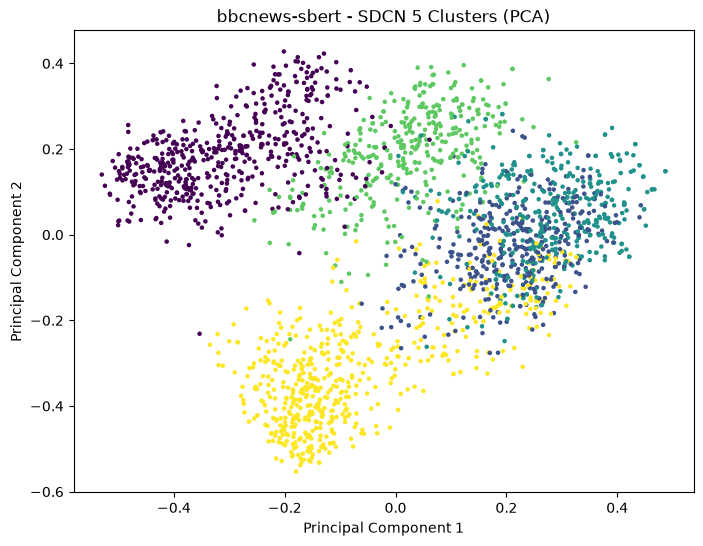


Running dataset: reuters with encoder: sbert
[Graph] Nodes: 7674
[Graph] Edges: 66566
[Graph] Density: 0.00113034

[SDCN] Pretraining AE...

[SDCN] Semantic refinement ON (gamma=1, semantic_dim=768)
[SDCN] Dynamic KNN ON (rebuild every 10 epochs from z_refined)

[SDCN] Joint Training...

semantic_proj: torch.Size([7674, 64])
structural_proj: torch.Size([7674, 64])
semantic projection gradient: 7.972784078447148e-05
structural projection gradient: 3.4402532037347555e-05
[Graph] Dynamic KNN rebuilt at epoch 0 (edges=58666)
[SDCN] Epoch 0 | Loss=2.9957 | KL=0.1286 | GCN_KL=0.6331 | RE=0.0025
semantic_proj: torch.Size([7674, 64])
structural_proj: torch.Size([7674, 64])
semantic projection gradient: 7.631168409716338e-05
structural projection gradient: 3.386508615221828e-05
semantic_proj: torch.Size([7674, 64])
structural_proj: torch.Size([7674, 64])
semantic projection gradient: 8.375919423997402e-05
structural projection gradient: 4.0614082536194474e-05
semantic_proj: torch.Size([7674, 6

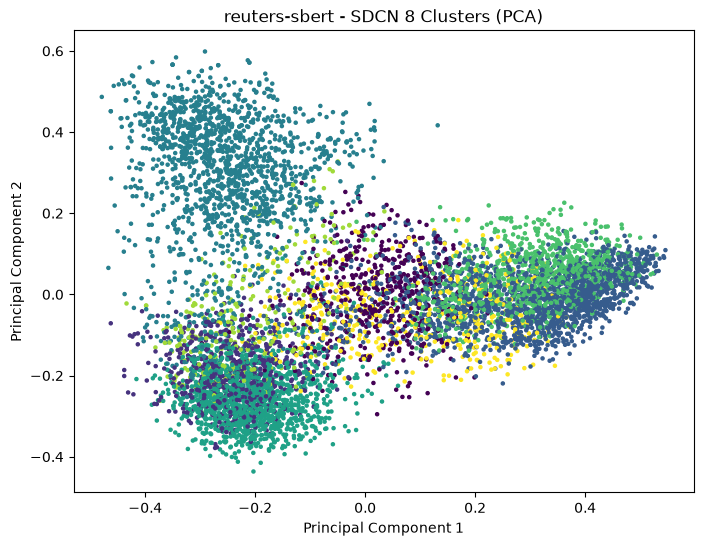


Running dataset: 20newsgroups with encoder: sbert
[Graph] Nodes: 18331
[Graph] Edges: 161313
[Graph] Density: 0.00048006

[SDCN] Pretraining AE...

[SDCN] Semantic refinement ON (gamma=1, semantic_dim=768)
[SDCN] Dynamic KNN ON (rebuild every 10 epochs from z_refined)

[SDCN] Joint Training...

semantic_proj: torch.Size([18331, 64])
structural_proj: torch.Size([18331, 64])
semantic projection gradient: 3.8996753573883325e-05
structural projection gradient: 1.889016493805684e-05
[Graph] Dynamic KNN rebuilt at epoch 0 (edges=142789)
[SDCN] Epoch 0 | Loss=3.0811 | KL=0.0836 | GCN_KL=0.3382 | RE=0.0027
semantic_proj: torch.Size([18331, 64])
structural_proj: torch.Size([18331, 64])
semantic projection gradient: 4.7408684622496367e-05
structural projection gradient: 2.557416337367613e-05
semantic_proj: torch.Size([18331, 64])
structural_proj: torch.Size([18331, 64])
semantic projection gradient: 5.713165592169389e-05
structural projection gradient: 3.297348303021863e-05
semantic_proj: torch

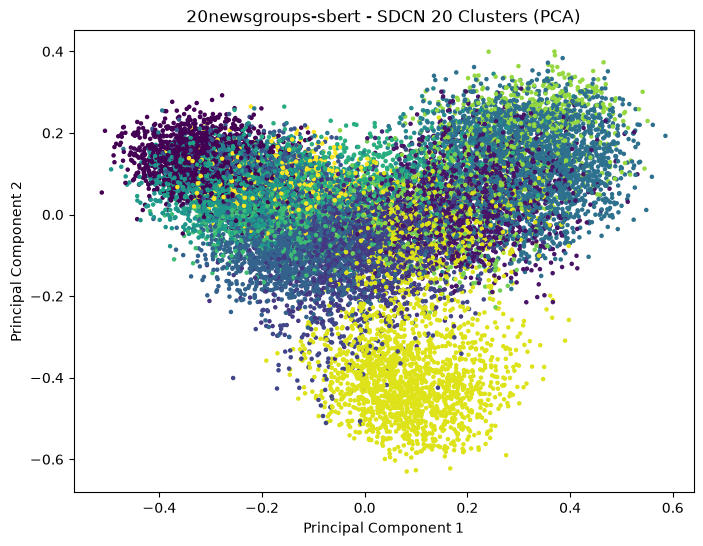


Running dataset: agnews with encoder: sbert
[Subset] Reducing dataset from 127600 to 20000
[Graph] Nodes: 20000
[Graph] Edges: 168714
[Graph] Density: 0.00042178

[SDCN] Pretraining AE...

[SDCN] Semantic refinement ON (gamma=1, semantic_dim=768)
[SDCN] Dynamic KNN ON (rebuild every 10 epochs from z_refined)

[SDCN] Joint Training...

semantic_proj: torch.Size([20000, 64])
structural_proj: torch.Size([20000, 64])
semantic projection gradient: 2.8451271646190435e-05
structural projection gradient: 2.099080666084774e-05
[Graph] Dynamic KNN rebuilt at epoch 0 (edges=151120)
[SDCN] Epoch 0 | Loss=3.0901 | KL=0.0722 | GCN_KL=0.3091 | RE=0.0030
semantic_proj: torch.Size([20000, 64])
structural_proj: torch.Size([20000, 64])
semantic projection gradient: 3.495769851724617e-05
structural projection gradient: 2.5585006369510666e-05
semantic_proj: torch.Size([20000, 64])
structural_proj: torch.Size([20000, 64])
semantic projection gradient: 4.32878514402546e-05
structural projection gradient: 3.

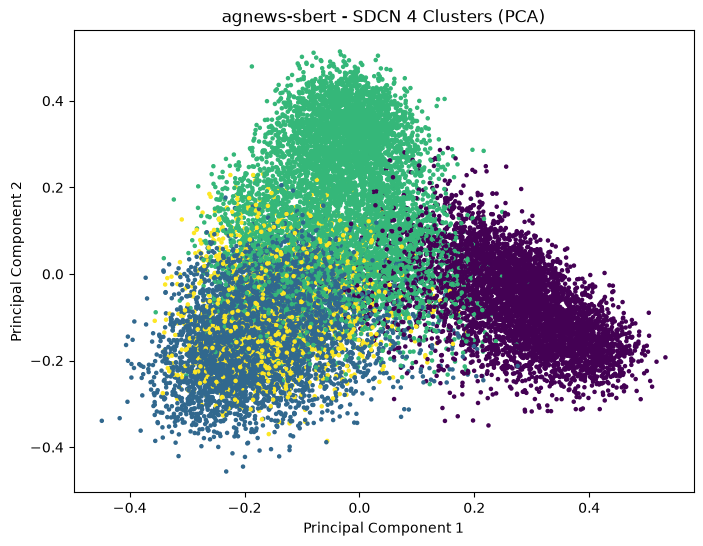


Running dataset: dbpedia with encoder: sbert
[Subset] Reducing dataset from 150000 to 20000
[Graph] Nodes: 20000
[Graph] Edges: 172582
[Graph] Density: 0.00043146

[SDCN] Pretraining AE...

[SDCN] Semantic refinement ON (gamma=1, semantic_dim=768)
[SDCN] Dynamic KNN ON (rebuild every 10 epochs from z_refined)

[SDCN] Joint Training...

semantic_proj: torch.Size([20000, 64])
structural_proj: torch.Size([20000, 64])
semantic projection gradient: 4.9464317271485925e-05
structural projection gradient: 3.409895725781098e-05
[Graph] Dynamic KNN rebuilt at epoch 0 (edges=156602)
[SDCN] Epoch 0 | Loss=3.0905 | KL=0.1257 | GCN_KL=0.5042 | RE=0.0030
semantic_proj: torch.Size([20000, 64])
structural_proj: torch.Size([20000, 64])
semantic projection gradient: 5.9175861679250374e-05
structural projection gradient: 4.190203617326915e-05
semantic_proj: torch.Size([20000, 64])
structural_proj: torch.Size([20000, 64])
semantic projection gradient: 7.518351048929617e-05
structural projection gradient: 

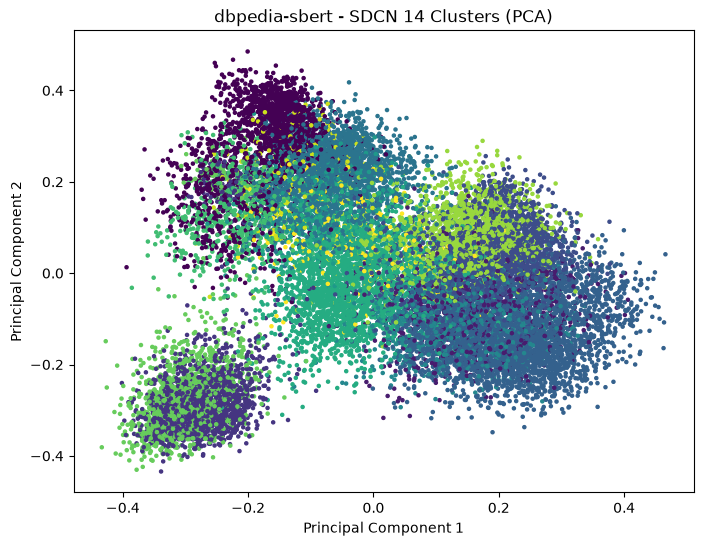

In [6]:
history = run_experiments(
    datasets_root="../embeddings",
    csv_path="../outputs/performance_metrics/results.csv"
)

In [7]:
import json
print("Done")
with open("../outputs/training_metrics/sdcn_track.json", "w") as f:
    json.dump(history, f, indent=4)

Done
